In [194]:
import os
import numpy as np
import matplotlib.pyplot as plt

# GDS factrory imports
import gdsfactory as gf
from gdsfactory.typings import Layer


# NOTE: In GDS factory all dimensions are in um.

# Thermocouple PDK

In [ ]:
class 

In [230]:
# Define an explicit cross-section function matching your reference style
def custom_metal_cross_section(width=10.0, radius=50.0, layer=(1, 0)):
    return gf.cross_section.cross_section(
        layer=layer, 
        width=width, 
        radius=None
    )

Frame cell. The active region of the slide available for making TCs

In [196]:
# 15 mm x 15 mm area usable on slide. 

@gf.cell
def die(
    size: gf.typings.Size = (10000.0, 10000.0),
    street_width: float = 100.0,
    street_length: float = 1000.0,
    die_name: str | None = "chip99",
    text_size: float = 100.0,
    text_location: str | gf.typings.Float2 = "SW",
    layer: gf.typings.LayerSpec | None = "FLOORPLAN",
    bbox_layer: gf.typings.LayerSpec | None = "FLOORPLAN",
    text: gf.typings.ComponentSpec = "text",
    draw_corners: bool = False,
) -> gf.Component:
    """Returns die with optional markers marking the boundary of the die.

    Args:
        size: x, y dimensions of the die.
        street_width: Width of the corner marks for die-sawing.
        street_length: Length of the corner marks for die-sawing.
        die_name: Label text. If None, no label is added.
        text_size: Label text size.
        text_location: {'NW', 'N', 'NE', 'SW', 'S', 'SE'} or (x, y) coordinate.
        layer: For street widths. None to not draw the street widths.
        bbox_layer: optional bbox layer drawn bounding box around the die.
        text: function use for generating text. Needs to accept text, size, layer.
        draw_corners: True draws only corners. False draws a square die.
    """
    c = gf.Component()
    sx, sy = size[0] / 2, size[1] / 2

    if layer:
        if not draw_corners:
            street_length = sx
        xpts = np.array(
            [
                sx,
                sx,
                sx - street_width,
                sx - street_width,
                sx - street_length,
                sx - street_length,
            ]
        )
        if not draw_corners:
            street_length = sy
        ypts = np.array(
            [
                sy,
                sy - street_length,
                sy - street_length,
                sy - street_width,
                sy - street_width,
                sy,
            ]
        )
        c.add_polygon(list(zip(xpts, ypts, strict=False)), layer=layer)
        c.add_polygon(list(zip(-xpts, ypts, strict=False)), layer=layer)
        c.add_polygon(list(zip(xpts, -ypts, strict=False)), layer=layer)
        c.add_polygon(list(zip(-xpts, -ypts, strict=False)), layer=layer)

    if bbox_layer:
        c.add_polygon([(sx, sy), (sx, -sy), (-sx, -sy), (-sx, sy)], layer=bbox_layer)

    if die_name:
        text_component = gf.get_component(
            text, text=die_name, size=text_size, layer="TEXT"
        )
        t = c.add_ref(text_component)

        d = street_width + 20
        if isinstance(text_location, str):
            text_location = text_location.upper()
            if text_location == "N":
                t.x, t.ymax = [0, sy - d]
            elif text_location == "NE":
                t.xmax, t.ymax = [sx - d, sy - d]
            elif text_location == "NW":
                t.xmin, t.ymax = [-sx + d, sy - d]
            elif text_location == "S":
                t.x, t.ymin = [0, -sy + d]
            elif text_location == "SE":
                t.xmax, t.ymin = [sx - d, -sy + d]
            elif text_location == "SW":
                t.xmin, t.ymin = [-sx + d, -sy + d]
            else:
                raise ValueError(
                    f"Invalid text_location: {text_location} not in N, NE, NW, S, SE, SW"
                )
        else:
            t.x, t.y = text_location

    return c

Contact Pads (0.5 mm squared)

In [197]:
# 0.5 mm x 0.5 mm contact pad.

@gf.cell
def contact_pad(
    size: gf.typings.Size = (500.0, 500.0),
    layer: gf.typings.LayerSpec = (1, 0),
    port_width: float = 10.0,
    port_orientation: float = 0.0, # 0=Right, 90=Top, 180=Left, 270=Bottom
) -> gf.Component:
    """Returns a square/rectangular contact pad with a connection port.

    Args:
        size: Width (x) and height (y) dimensions of the contact pad.
        layer: GDS layer for the pad metal.
        port_width: Width of the trace connection track port.
        port_orientation: Angle of the port facing direction in degrees.
    """
    c = gf.Component()
    sx, sy = size[0] / 2.0, size[1] / 2.0

    # 1. Draw the main square pad centered at (0, 0)
    c.add_polygon(
        [(-sx, -sy), (sx, -sy), (sx, sy), (-sx, sy)], 
        layer=layer
    )

    # 2. Add an optical/electrical port for track routing
    # We position the port precisely on the edge based on user orientation
    if port_orientation == 0.0:     # Right edge
        port_center = (sx, 0.0)
    elif port_orientation == 90.0:   # Top edge
        port_center = (0.0, sy)
    elif port_orientation == 180.0:  # Left edge
        port_center = (-sx, 0.0)
    elif port_orientation == 270.0:  # Bottom edge
        port_center = (0.0, -sy)
    else:
        # Fallback to center if a custom angle is input
        port_center = (0.0, 0.0)

    c.add_port(
        name="e1",                  # Port identifier name
        center=port_center,         # Exact connection point coordinate
        width=port_width,           # Matches your interconnect wire track width
        orientation=port_orientation, 
        layer=layer,
        port_type="electrical"      # Specifies this is for conductive paths
    )

    return c

Scalable object for the thermocouple overlap (junction)

In [198]:
@gf.cell
def thermocouple_junction(
    w: float = 3.0,                  # Overlap width (square overlap)
    layer_bottom: gf.typings.LayerSpec = (1, 0), # Au Bottom Layer
    layer_top: gf.typings.LayerSpec = (2, 0),    # Ni Top Layer
    text = True,
    offset_leg_l1 = 0,
    offset_leg_l2 = 0,
    port_orientation = 0,
    port_width=100,
) -> gf.Component:
    """Returns a scalable chiral thermocouple junction.
    
    The geometry scales dynamically based on the parameter `w`.
    Maintains a perfect vertical overlap contact zone at the center.
    """
    c = gf.Component()

    # 1. Generate parameterized coordinates based on 'w'
    coords_layer1 = [
        (0.0, 0.0 - offset_leg_l1),
        (0.0, 2 * w),
        (2 * w, 2 * w),
        (2 * w, w),
        (w, w),
        (w, 0.0 - offset_leg_l1),
        
    ]

    # Mirror horizontally and shift by 3*w to sit the chiral edge perfectly 
    # on the original (2*w, w) -> (w, w) segment.
    coords_layer2 = [(-x + 3 * w, y) for x, y in coords_layer1]
    # Adding offset on the legs for layer 2.
    # have to add offset l1 back because its copied from coords_layer1!!!!
    coords_layer2[0] = (coords_layer2[0][0], coords_layer2[0][1] - offset_leg_l2 + offset_leg_l1)
    coords_layer2[-1] = (coords_layer2[-1][0], coords_layer2[-1][1] - offset_leg_l2 + offset_leg_l1)

    # 2. Add Polygons
    c.add_polygon(coords_layer1, layer=layer_bottom)
    c.add_polygon(coords_layer2, layer=layer_top)

    # 3. Add Dynamic Labels centered in the non-overlapped vertical legs
    # Left leg center: X = 0.5*w, Y = 1.0*w
    if text:
        c.add_label(text="Au_Bottom_Layer", position=(0.35 * w, 1.0 * w), layer=layer_bottom)
    
        # Right leg center: X = 2.5*w, Y = 1.0*w
        c.add_label(text="Ni_Top_Layer", position=(2.35 * w, 1.0 * w), layer=layer_top)
        
        # Header label centered above the central junction area
        c.add_label(text=f"{int(w)}x{int(w)} Thermocouple", position=(1.5 * w, 2.2 * w), layer=(0, 0))

    # 4. Add Electrical Ports for easy track routing
    if port_orientation == 0:
        c.add_port(
            name="e1_gold",
            center=(0,-offset_leg_l1+port_width/2),
            width=w,
            orientation=0,
            layer=layer_bottom,
            port_type="electrical"
        )
        
        c.add_port(
            name="e2_nickel",
            center=(2 * w, -offset_leg_l2+port_width/2),
            width=w,
            orientation=0,
            layer=layer_top,
            port_type="electrical"
        )
        
    elif port_orientation == 180:
        c.add_port(
            name="e1_gold",
            center=(w,-offset_leg_l1+port_width/2),
            width=w,
            orientation=0,
            layer=layer_bottom,
            port_type="electrical"
        )
        
        c.add_port(
            name="e2_nickel",
            center=(3 * w, -offset_leg_l2+port_width/2),
            width=w,
            orientation=0,
            layer=layer_top,
            port_type="electrical"
        )

    return c

In [199]:
@gf.cell
def die_with_pads(
    die_size: tuple[float, float] = (15000.0, 15000.0),
    contactpad_size: float = 750.0,
    port_width: float = 100.0,
) -> gf.Component:
    """Returns a 15mm die frame populated with 24 custom contact pads along its edges."""
    
    # 1. Initialize the main container component
    c = gf.Component()

    # 2. Create and add the Frame
    frame_cell = die(
        size=die_size,
        street_width=150,         
        die_name="15mm_ActiveRegion", 
        text_location="SW",
        layer="FLOORPLAN",
        bbox_layer="FLOORPLAN",
        draw_corners=False        
    )
    c.add_ref(frame_cell)

    # 3. Generate the pad dictionary dynamically
    port_dict = {}
    for i in range(1, 25):
        if i <= 2:
            layer = (1, 0)
            orientation = 0.0
        elif i < 8:
            layer = ((i + 1) % 2 + 1, 0)
            orientation = 0.0
        elif i < 18:
            layer = ((i + 1) % 2 + 1, 0)
            orientation = 90.0
        else:
            layer = ((i + 1) % 2 + 1, 0)
            orientation = 180.0
            
        port_dict[f"cp{i}"] = contact_pad(
            size=(contactpad_size, contactpad_size), 
            layer=layer, 
            port_width=port_width, 
            port_orientation=orientation
        )

    # 4. Clearances and offsets for placement
    side_clearance = round((11000 - 7 * contactpad_size) / 6)
    bottom_clearance = round((11000 - 10 * contactpad_size) / 9)
    bottom_x_offset = -5500
    side_y_offset = 5500

    # 5. Place the references into the component
    for i in range(1, 25):
        ref = c << port_dict[f"cp{i}"]

        # Spreading the contact pads along Left, Bottom, and Right sides
        if i < 8:
            ref.center = (
                -die_size[0]/2 + 1.5 * contactpad_size, 
                side_y_offset - (side_clearance + contactpad_size) * (i - 1) - contactpad_size / 2
            )
        elif i < 18: 
            ref.center = (
                bottom_x_offset + (bottom_clearance + contactpad_size) * (i - 8) + contactpad_size / 2, 
                -die_size[1]/2 + 1.5 * contactpad_size
            )
        else:
            ref.center = (
                die_size[0]/2 - 1.5 * contactpad_size, 
                side_y_offset - (side_clearance + contactpad_size) * (i - 18) - contactpad_size / 2
            )
            
        # Optional: Proxy the ports of the pads to the main component cell if needed
        # c.add_ports(ref.ports, prefix=f"pad_{i}_")

    return c

In [200]:
# generic PDK
gf.gpdk.PDK.activate()

Example Thermocouple junction. gf.cell made above based on it. 

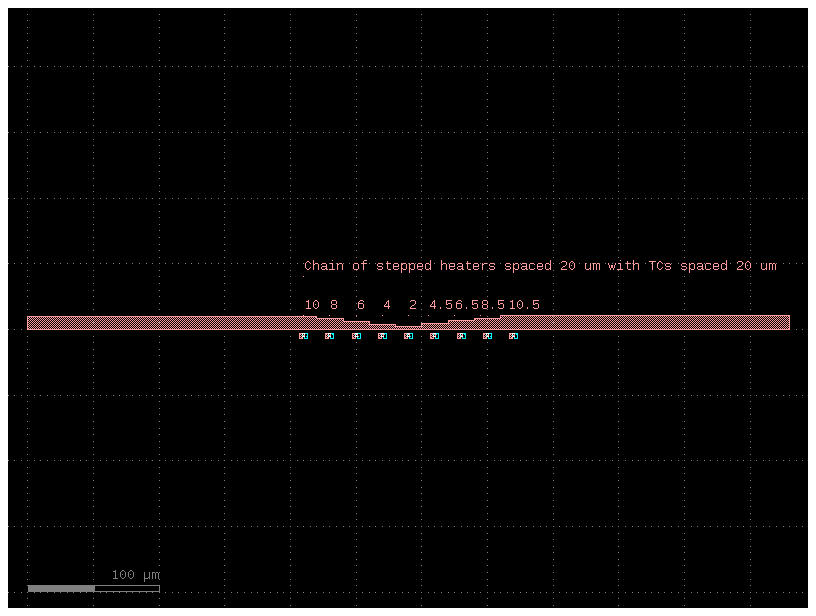

In [210]:
gf.clear_cache()

# blank component
heater = gf.Component("Stepped_Heater")

# 2. Define the original right-angled coordinates of the heater (Layer 1: Au layer)
stepped_heater_coords = [
    (-200.0, 0.0),
    (-200.0, 10.0),
    (20.0, 10.0),
    (20.0, 8.0),
    (40.0, 8.0),
    (40.0, 6.0),
    (60.0, 6.0),
    (60.0, 4.0),
    (80.0, 4.0),
    (80.0, 2.0),
    (100.0, 2.0),
    (100.0, 4.50),
    (120.0, 4.50),
    (120.0, 6.50),
    (140.0, 6.50),
    (140.0, 8.50),
    (160.0, 8.50),
    (160.0, 10.50),
    (180.0, 10.50),
    (380.0, 10.50),
    (380, 0),
    (-100, 0)
]

# Add poolygons to layers
p1 = heater.add_polygon(stepped_heater_coords, layer=(1, 0))

# Spacing centers of TCs by 20 um
for i in range(9):
    tc = thermocouple_junction(w=2, text=False)
    tc_ref = heater << tc
    tc_ref.center = (10 + 20 *i, -5)

heater.add_label(text="10", position = (10, 11), layer = (0,0))
heater.add_label(text="8", position = (30, 11), layer = (0,0))
heater.add_label(text="6", position = (50, 11), layer = (0,0))
heater.add_label(text="4", position = (70, 11), layer = (0,0))
heater.add_label(text="2", position = (90, 11), layer = (0,0))
heater.add_label(text="4.5", position = (105, 11), layer = (0,0))
heater.add_label(text="6.5", position = (125, 11), layer = (0,0))
heater.add_label(text="8.5", position = (145, 11), layer = (0,0))
heater.add_label(text="10.5", position = (165, 11), layer = (0,0))

descriptor = "Chain of stepped heaters spaced 20 um with TCs spaced 20 um"
heater.add_label(text=descriptor, position = (10, 40), layer = (0,0))

heater.write_gds("sample_stepped_heater.gds")
heater.plot()

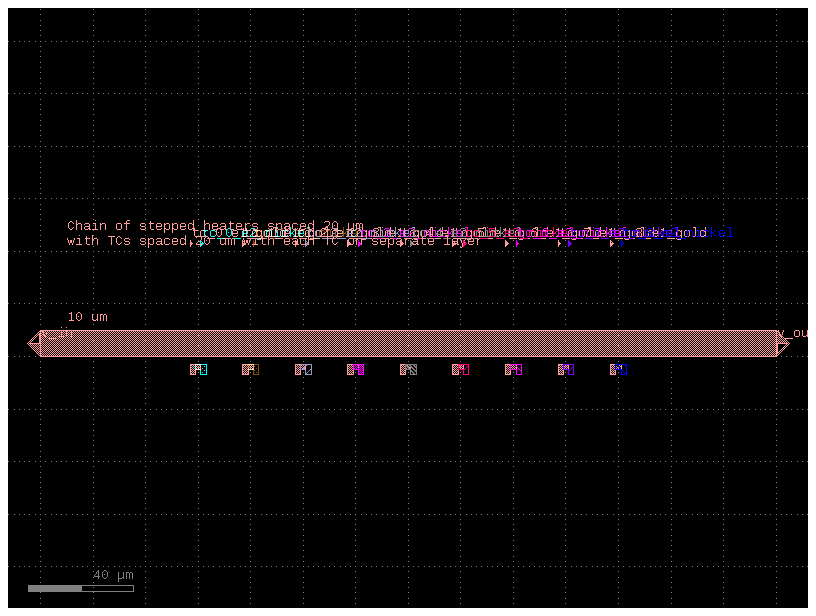

In [202]:
gf.clear_cache()

# blank component
single_heater = gf.Component("Single_Heater")

# 2. Define the original right-angled coordinates of the heater (Layer 1: Au layer)
coords_layer1 = [
    (0.0, 0.0),
    (0.0, 10.0),
    (280.0, 10.0),
    (280, 0),
    (0, 0)
]

# Add poolygons to layers
p1 = single_heater.add_polygon(coords_layer1, layer=(1, 0))

# 10 um port either side
single_heater.add_port(name="v_in",
    center=(0.0, 5),
    width=10,
    orientation=180,
    layer=(1,0),
    port_type="electrical"
)

single_heater.add_port(name="v_out",
    center=(280, 5),
    width=10,
    orientation=0,
    layer=(1,0),
    port_type="electrical"
)

# Spacing centers of TCs by 20 um
for i in range(9):
    tc = thermocouple_junction(w=2, layer_top = (i+2,0), text=False)
    tc_ref = single_heater << tc
    tc_ref.center = (60 + 20 *i, -5)

    # Inherit TC ports. This is important!!
    single_heater.add_ports(tc_ref.ports, prefix=f"tc_{i}_")

    # referenced as single_heater.ports["tc_0_e1_gold"] etc.

single_heater.add_label(text="10 um", position = (10, 11), layer = (0,0))

descriptor = "Chain of stepped heaters spaced 20 um\nwith TCs spaced 20 um with each TC on separate layer"
single_heater.add_label(text=descriptor, position = (10, 40), layer = (0,0))

single_heater.write_gds("sample_multi_layer_TCs.gds")
single_heater.draw_ports()
single_heater.plot()

## Putting these components together in a single GDS: Multi Layer TCs

Side Pad Spacing: 958 um
Bottom Pad Spacing: 389 um


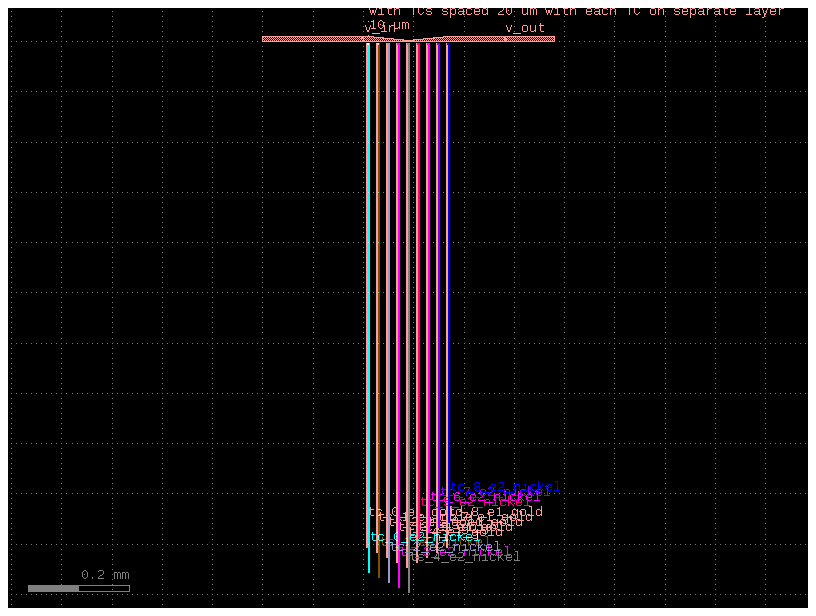

In [219]:
gf.clear_cache()

# Main Component. All components above will be added here. 
TC = gf.Component("Example combination of sample TC and Frame")

# ====================== 15 x 15 Frame ====================== #

# Components to add to main component
Frame = die(
    size=(15000, 15000),      # 15 mm x 15 mm
    street_width=150,         
    die_name="15mm_ActiveRegion", 
    text_location="SW",       # text bottom left
    layer="FLOORPLAN",
    bbox_layer="FLOORPLAN",
    draw_corners=False        
)
addFrame = TC.add_ref(Frame)

# ====================== Contact Pads ====================== #
# Creating Contact pads assigned to each layer with ports oriented per PCB design. 
# need to add power and ground to bottom layer and then every second one to Au/Ni layers. 
# layer setting is mod 2 so every second one is on a different layer.
port_dict = {}
contactpad_size = 750
for i in range(1,25):
    if i <= 2:
        port_dict[f"cp{i}"] = contact_pad(size=(contactpad_size, contactpad_size), layer=(1, 0), port_width=100.0, port_orientation=0.0)
    elif i < 8:
        port_dict[f"cp{i}"] = contact_pad(size=(contactpad_size, contactpad_size), layer=((i+1) % 2 + 1, 0), port_width=100.0, port_orientation=0.0)
    elif i < 18:
        port_dict[f"cp{i}"] = contact_pad(size=(contactpad_size, contactpad_size), layer=((i+1) % 2 + 1, 0), port_width=100.0, port_orientation=90.0)
    else:
        port_dict[f"cp{i}"] = contact_pad(size=(contactpad_size, contactpad_size), layer=((i+1) % 2 + 1, 0), port_width=100.0, port_orientation=180.0)
        
side_clearance =  round((11000 - 7 * contactpad_size) / 6)
bottom_clearance = round((11000 - 10 * contactpad_size) / 9)
bottom_x_offset = -5500
side_y_offset = 5500

print(f"Side Pad Spacing: {side_clearance} um\nBottom Pad Spacing: {bottom_clearance} um")

# Adding directional ports to the contact pads
add_port_dict = {}
for i in range(1,25):
    add_port_dict[f"add_cp{i}"] = TC << port_dict[f"cp{i}"]
    # Here, I need to spread the contact pads evenly along each side. (1,7)L, (8,17)B, (18,24)R
    if i < 8:
        add_port_dict[f"add_cp{i}"].center = (-7500 + 1.5 * contactpad_size, side_y_offset - (side_clearance + contactpad_size) * (i-1) - contactpad_size/2)
    elif i < 18: 
        add_port_dict[f"add_cp{i}"].center = (bottom_x_offset + (bottom_clearance + contactpad_size) * (i-8) + contactpad_size/2, -7500 + 1.5 * contactpad_size)
    else:
        add_port_dict[f"add_cp{i}"].center = (7500 - 1.5 * contactpad_size, side_y_offset - (side_clearance + contactpad_size) * (i-18)  -contactpad_size/2)

# ======================= Adding TCs ======================= #

single_heater = gf.Component("Single_Heater")
descriptor = "Chain of stepped heaters spaced 20 um\nwith TCs spaced 20 um with each TC on separate layer"

# 2. Define the original right-angled coordinates of the heater (Layer 1: Au layer)
heater_coords = [
    (0.0, 0.0),
    (0.0, 10.0),
    (280.0, 10.0),
    (280, 0),
    (0, 0)
]

# Add poolygons to layers
p1 = single_heater.add_polygon(stepped_heater_coords, layer=(1, 0))

# 10 um port either side
single_heater.add_port(name="v_in",
    center=(0.0, 5),
    width=10,
    orientation=180,
    layer=(1,0),
    port_type="electrical"
)

single_heater.add_port(name="v_out",
    center=(280, 5),
    width=10,
    orientation=0,
    layer=(1,0),
    port_type="electrical"
)

# Spacing centers of TCs by 20 um

for i in range(9):
    if i < 5:    
        tc_leg_offset = 1000 + 10 * i
        differential_offset = 50
    else:
        tc_leg_offset = 1000 + 10 * (8-i)
        differential_offset = -50
    tc = thermocouple_junction(w=2, layer_top = (i+2,0), text=False, offset_leg_l1=tc_leg_offset, offset_leg_l2= tc_leg_offset + differential_offset)
    tc_ref = single_heater << tc
    if i < 5:
        tc_ref.center = (8.5 + 20 *i, - 5 - (tc_leg_offset + differential_offset)/2)
    else:
        # The differential is because its now shorter not longer than the offset
        tc_ref.center = (8.5 + 20 *i, - 5 + differential_offset/2 - (tc_leg_offset + differential_offset)/2)

    # REmember to inherit the PORTS!!! I keep forgetting!
    single_heater.add_ports(tc_ref.ports, prefix=f"tc_{i}_")

single_heater.add_label(text="10 um", position = (10, 11), layer = (0,0))
single_heater.add_label(text=descriptor, position = (10, 40), layer = (0,0))

single_heater.write_gds("sample_multi_layer_stepped_heater_TCs.gds")
single_heater.draw_ports()
single_heater.plot()

In [204]:
# gf.clear_cache()

# t = gf.Component("testt")

# dwp = die_with_pads()

# t.add_ref(dwp)

# t.plot()

In [205]:
# x = thermocouple_junction()
# x.ports['e1_gold']
# x.ports['e2_nickel']

In [231]:
gf.clear_cache()
TC = gf.Component("Example combination of sample TC and Frame")

# ================= Frame ================= #
Frame = die(
    size=(15000, 15000),      # 15 mm x 15 mm
    street_width=150,         
    die_name="15mm_ActiveRegion", 
    text_location="SW",       # text bottom left
    layer="FLOORPLAN",
    bbox_layer="FLOORPLAN",
    draw_corners=False        
)
addFrame = TC.add_ref(Frame)

# ================= Contact Pads ================= #

port_dict = {}
contactpad_size = 750

# Generate pad component definitions
for i in range(1, 25):
    if i <= 2:
        port_dict[f"cp{i}"] = contact_pad(size=(contactpad_size, contactpad_size), layer=(1, 0), port_width=100.0, port_orientation=0.0)
    elif i < 8:
        port_dict[f"cp{i}"] = contact_pad(size=(contactpad_size, contactpad_size), layer=((i+1) % 2 + 1, 0), port_width=100.0, port_orientation=0.0)
    elif i < 18:
        port_dict[f"cp{i}"] = contact_pad(size=(contactpad_size, contactpad_size), layer=((i+1) % 2 + 1, 0), port_width=100.0, port_orientation=90.0)
    else:
        port_dict[f"cp{i}"] = contact_pad(size=(contactpad_size, contactpad_size), layer=((i+1) % 2 + 1, 0), port_width=100.0, port_orientation=180.0)
        
side_clearance = round((11000 - 7 * contactpad_size) / 6)
bottom_clearance = round((11000 - 10 * contactpad_size) / 9)
bottom_x_offset = -5500
side_y_offset = 5500

print(f"Side Pad Spacing: {side_clearance} um\nBottom Pad Spacing: {bottom_clearance} um")

# Add pads as references and inherit ports to master component
add_port_dict = {}
for i in range(1, 25):
    ref = TC << port_dict[f"cp{i}"]
    add_port_dict[f"add_cp{i}"] = ref
    
    # Spread the contact pads evenly along each side: (1,7)Left, (8,17)Bottom, (18,24)Right
    if i < 8:
        ref.center = (-7500 + 1.5 * contactpad_size, side_y_offset - (side_clearance + contactpad_size) * (i-1) - contactpad_size/2)
    elif i < 18: 
        ref.center = (bottom_x_offset + (bottom_clearance + contactpad_size) * (i-8) + contactpad_size/2, -7500 + 1.5 * contactpad_size)
    else:
        ref.center = (7500 - 1.5 * contactpad_size, side_y_offset - (side_clearance + contactpad_size) * (i-18) - contactpad_size/2)

    # SUCCESS: Exposing pad ports up to the main master component
    TC.add_ports(ref.ports, prefix=f"pad_{i}_")


# ================= Heater Sub-Component ================= #
single_heater = gf.Component("Single_Heater")
descriptor = "Chain of stepped heaters spaced 20 um\nwith TCs spaced 20 um with each TC on separate layer"

# Define the coordinates of the heater (Layer 1: Au layer)
heater_coords = [
    (-100.0, 0.0),
    (-100.0, 10.0),
    (380.0, 10.0),
    (380, 0),
    (-100, 0)
]

# Add polygon to heater (stepped_heater_coords for stepped heater)
p1 = single_heater.add_polygon(heater_coords, layer=(1, 0))

# 10 um port on either side of the heater trace
single_heater.add_port(
    name="v_in",
    center=(-50, 10),
    width=100,
    orientation=90,
    layer=(1,0),
    port_type="electrical"
)

single_heater.add_port(
    name="v_out",
    center=(330, 10),
    width=100,
    orientation=90,
    layer=(1,0),
    port_type="electrical"
)

# ================= Thermocouples Sub-Component ================= #
# Instantiate and space 9 Thermocouple Junctions by 20 um
# Making the TC's single layer. To adjust chance layer_top = (i+2, 0) which makes a new layer for each TC for multi thickness tests.
for i in range(9):
    if i < 5:    
        tc_leg_offset = 1000 + 1000 * i
        differential_offset = 200
        tc = thermocouple_junction(w=2, layer_top = (2,0), text=False, offset_leg_l1=tc_leg_offset, offset_leg_l2= tc_leg_offset + differential_offset)
    else:
        tc_leg_offset = 1000 + 1000 * (8-i)
        differential_offset = -200
        tc = thermocouple_junction(w=2, layer_top = (2,0), text=False, offset_leg_l1=tc_leg_offset, offset_leg_l2= tc_leg_offset + differential_offset, port_orientation=180)
    tc_ref = single_heater << tc
    if i < 5:
        # offset 8.5 for stepped heater not 60 (60 is arbitrary)
        tc_ref.center = (60 + 20 *i, - 5 - (tc_leg_offset + differential_offset)/2)
    else:
        # The differential is because its now shorter not longer than the offset
        tc_ref.center = (60 + 20 *i, - 5 + differential_offset/2 - (tc_leg_offset + differential_offset)/2)

    # REmember to inherit the PORTS!!! I keep forgetting!
    single_heater.add_ports(tc_ref.ports, prefix=f"tc_{i}_")

single_heater.add_label(text="10 um", position=(10, 11), layer=(0,0))
single_heater.add_label(text=descriptor, position=(10, 40), layer=(0,0))


# ================= Heater Assembly ================= #
heater_ref = TC << single_heater
heater_ref.center = (0, 0) # Placing it perfectly dead-center of your 15mm frame

# Inherit the heater and sub-TC ports up to the master structure as well
TC.add_ports(heater_ref.ports, prefix="heater_")

# ================= Routing ================= #
gf.routing.route_bundle(
    TC,
    ports1=[TC.ports["pad_2_e1"]],    # Wrapped in a list
    ports2=[TC.ports["heater_v_in"]],  # Wrapped in a list
    cross_section=custom_metal_cross_section(width=100.0, radius=100),
    port_type="electrical",
    auto_taper=False,
)

gf.routing.route_bundle(
    TC,
    ports1=[TC.ports["pad_1_e1"]],    # Wrapped in a list
    ports2=[TC.ports["heater_v_out"]],  # Wrapped in a list
    cross_section=custom_metal_cross_section(width=100.0, radius=100),
    auto_taper=False,
)

gf.routing.route_bundle(
    TC,
    ports2=[TC.ports["pad_3_e1"]],    # Wrapped in a list
    ports1=[TC.ports["heater_tc_0_e1_gold"]],  # Wrapped in a list
    cross_section=custom_metal_cross_section(width=100.0, radius=100),
    start_angles=[180],
    auto_taper=False,
)

gf.routing.route_bundle(
    TC,
    ports2=[TC.ports["pad_4_e1"]],    # Wrapped in a list
    ports1=[TC.ports["heater_tc_0_e2_nickel"]],  # Wrapped in a list
    cross_section=custom_metal_cross_section(width=100.0, radius=100, layer=(2,0)),
    start_angles=[180],
    auto_taper=False,
)

gf.routing.route_bundle(
    TC,
    ports2=[TC.ports["pad_5_e1"]],    # Wrapped in a list
    ports1=[TC.ports["heater_tc_1_e1_gold"]],  # Wrapped in a list
    cross_section=custom_metal_cross_section(width=100.0, radius=100),
    start_angles=[180],
    auto_taper=False,
)

gf.routing.route_bundle(
    TC,
    ports2=[TC.ports["pad_6_e1"]],    # Wrapped in a list
    ports1=[TC.ports["heater_tc_1_e2_nickel"]],  # Wrapped in a list
    cross_section=custom_metal_cross_section(width=100.0, radius=100, layer=(2,0)),
    start_angles=[180],
    auto_taper=False,
)

gf.routing.route_bundle(
    TC,
    ports2=[TC.ports["pad_7_e1"]],    # Wrapped in a list
    ports1=[TC.ports["heater_tc_2_e1_gold"]],  # Wrapped in a list
    cross_section=custom_metal_cross_section(width=100.0, radius=100),
    start_angles=[180],
    auto_taper=False,
)

gf.routing.route_bundle(
    TC,
    ports2=[TC.ports["pad_8_e1"]],    # Wrapped in a list
    ports1=[TC.ports["heater_tc_2_e2_nickel"]],  # Wrapped in a list
    cross_section=custom_metal_cross_section(width=100.0, radius=100, layer=(2,0)),
    start_angles=[180],
    auto_taper=False,
)

gf.routing.route_bundle(
    TC,
    ports2=[TC.ports["pad_9_e1"]],    # Wrapped in a list
    ports1=[TC.ports["heater_tc_3_e1_gold"]],  # Wrapped in a list
    cross_section=custom_metal_cross_section(width=100.0, radius=100),
    start_angles=[180],
    auto_taper=False,
)

gf.routing.route_bundle(
    TC,
    ports2=[TC.ports["pad_10_e1"]],    # Wrapped in a list
    ports1=[TC.ports["heater_tc_3_e2_nickel"]],  # Wrapped in a list
    cross_section=custom_metal_cross_section(width=100.0, radius=100, layer=(2,0)),
    start_angles=[180],
    auto_taper=False,
)

gf.routing.route_bundle(
    TC,
    ports2=[TC.ports["pad_11_e1"]],    # Wrapped in a list
    ports1=[TC.ports["heater_tc_4_e1_gold"]],  # Wrapped in a list
    cross_section=custom_metal_cross_section(width=100.0, radius=100),
    start_angles=[180],
    auto_taper=False,
)

gf.routing.route_bundle(
    TC,
    ports2=[TC.ports["pad_12_e1"]],    # Wrapped in a list
    ports1=[TC.ports["heater_tc_4_e2_nickel"]],  # Wrapped in a list
    cross_section=custom_metal_cross_section(width=100.0, radius=100, layer=(2,0)),
    start_angles=[180],
    auto_taper=False,
)

gf.routing.route_bundle(
    TC,
    ports2=[TC.ports["pad_15_e1"]],    # Wrapped in a list
    ports1=[TC.ports["heater_tc_5_e1_gold"]],  # Wrapped in a list
    cross_section=custom_metal_cross_section(width=100.0, radius=100),
    start_angles=[180],
    auto_taper=False,
)

gf.routing.route_bundle(
    TC,
    ports2=[TC.ports["pad_16_e1"]],    # Wrapped in a list
    ports1=[TC.ports["heater_tc_5_e2_nickel"]],  # Wrapped in a list
    cross_section=custom_metal_cross_section(width=100.0, radius=100, layer=(2,0)),
    start_angles=[180],
    auto_taper=False,
)

gf.routing.route_bundle(
    TC,
    ports2=[TC.ports["pad_17_e1"]],    # Wrapped in a list
    ports1=[TC.ports["heater_tc_6_e1_gold"]],  # Wrapped in a list
    cross_section=custom_metal_cross_section(width=100.0, radius=100),
    start_angles=[180],
    auto_taper=False,
)

gf.routing.route_bundle(
    TC,
    ports2=[TC.ports["pad_18_e1"]],    # Wrapped in a list
    ports1=[TC.ports["heater_tc_6_e2_nickel"]],  # Wrapped in a list
    cross_section=custom_metal_cross_section(width=100.0, radius=100, layer=(2,0)),
    start_angles=[180],
    auto_taper=False,
)

gf.routing.route_bundle(
    TC,
    ports2=[TC.ports["pad_19_e1"]],    # Wrapped in a list
    ports1=[TC.ports["heater_tc_7_e1_gold"]],  # Wrapped in a list
    cross_section=custom_metal_cross_section(width=100.0, radius=100),
    start_angles=[180],
    auto_taper=False,
)

gf.routing.route_bundle(
    TC,
    ports2=[TC.ports["pad_20_e1"]],    # Wrapped in a list
    ports1=[TC.ports["heater_tc_7_e2_nickel"]],  # Wrapped in a list
    cross_section=custom_metal_cross_section(width=100.0, radius=100, layer=(2,0)),
    start_angles=[180],
    auto_taper=False,
)

gf.routing.route_bundle(
    TC,
    ports2=[TC.ports["pad_21_e1"]],    # Wrapped in a list
    ports1=[TC.ports["heater_tc_8_e1_gold"]],  # Wrapped in a list
    cross_section=custom_metal_cross_section(width=100.0, radius=100),
    start_angles=[180],
    auto_taper=False,
)

gf.routing.route_bundle(
    TC,
    ports2=[TC.ports["pad_22_e1"]],    # Wrapped in a list
    ports1=[TC.ports["heater_tc_8_e2_nickel"]],  # Wrapped in a list
    cross_section=custom_metal_cross_section(width=100.0, radius=100, layer=(2,0)),
    start_angles=[180],
    auto_taper=False,
)


TC.write_gds("IntegratedTCArray.gds")

# This will now visualize ALL outer contact pads, heater ports, and sub-TC ports collectively
TC.draw_ports()
TC.plot()

Side Pad Spacing: 958 um
Bottom Pad Spacing: 389 um


ValueError: radius must be specified

In [224]:
help(gf.routing.route_bundle)

Help on function route_bundle in module gdsfactory.routing.route_bundle:

route_bundle(component: 'gf.Component', ports1: 'Port | Ports | list[Pin] | None' = None, ports2: 'Port | Ports | list[Pin] | None' = None, cross_section: 'CrossSectionSpec | None' = None, layer: 'LayerSpec | None' = None, separation: 'float' = 3.0, bend: 'ComponentSpec' = 'bend_euler', sort_ports: 'bool' = False, start_straight_length: 'float' = 0, end_straight_length: 'float' = 0, min_straight_taper: 'float' = 100, taper: 'ComponentSpec | None' = None, port_type: 'str | None' = None, collision_check_layers: 'LayerSpecs | None' = None, on_collision: "Literal['error', 'show_error', 'warning'] | None" = None, on_placer_error: "Literal['error', 'show_error', 'warning'] | None" = None, bboxes: 'Sequence[kf.kdb.DBox] | None' = None, allow_width_mismatch: 'bool | None' = None, allow_layer_mismatch: 'bool | None' = None, allow_type_mismatch: 'bool | None' = None, radius: 'float | None' = None, route_width: 'float | Non